In [1]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no GPU')
!pip install -q segmentation-models-pytorch rasterio
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/flood-event-water-mapping'
for directory in ['checkpoints', 'results', 'figures']:
    os.makedirs(f'{BASE}/{directory}', exist_ok=True)

True Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.4 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
!gsutil ls gs://sen1floods11/v1.1/
!gsutil ls gs://sen1floods11/v1.1/data/flood_events/HandLabeled/
!gsutil ls gs://sen1floods11/v1.1/splits/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://sen1floods11/v1.1/Sen1Floods11_Metadata.geojson
gs://sen1floods11/v1.1/catalog.zip
gs://sen1floods11/v1.1/catalog/
gs://sen1floods11/v1.1/checkpoints/
gs://sen1floods11/v1.1/data/
gs://sen1floods11/v1.1/splits/
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1OtsuLabelHand/
gs:/

In [3]:
!mkdir -p /content/data/S1Hand /content/data/S2Hand /content/data/LabelHand /content/data/splits

!gsutil -m cp -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/* /content/data/S1Hand/
!gsutil -m cp -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/* /content/data/S2Hand/
!gsutil -m cp -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/* /content/data/LabelHand/
!gsutil -m cp -r gs://sen1floods11/v1.1/splits/flood_handlabeled/* /content/data/splits/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_129334_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_103757_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_195474_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_23014_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_233925_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_242570_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_312675_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1

In [4]:
!ls /content/data/S1Hand | head -5
!ls /content/data/S1Hand | wc -l
!ls /content/data/S2Hand | wc -l
!ls /content/data/LabelHand | wc -l
!ls /content/data/splits

Bolivia_103757_S1Hand.tif
Bolivia_129334_S1Hand.tif
Bolivia_195474_S1Hand.tif
Bolivia_23014_S1Hand.tif
Bolivia_233925_S1Hand.tif
446
446
446
flood_bolivia_data.csv	flood_train_data.csv
flood_test_data.csv	flood_valid_data.csv


In [5]:
import pandas as pd, glob, os

for name in ['train', 'valid', 'test', 'bolivia']:
    df = pd.read_csv(f'/content/data/splits/flood_{name}_data.csv', header=None)
    regions = df[0].str.split('_').str[0].value_counts()
    print(f'\n{name}: {len(df)} chips from {len(regions)} regions')
    print(df.head(2).to_string(header=False))
    print(regions.to_string())


train: 252 chips from 10 regions
0  Ghana_103272_S1Hand.tif  Ghana_103272_LabelHand.tif
1   Ghana_24858_S1Hand.tif   Ghana_24858_LabelHand.tif
0
USA          41
India        40
Paraguay     39
Ghana        31
Sri-Lanka    24
Mekong       18
Spain        18
Pakistan     16
Somalia      15
Nigeria      10

valid: 89 chips from 10 regions
0    Ghana_5079_S1Hand.tif    Ghana_5079_LabelHand.tif
1  Ghana_895194_S1Hand.tif  Ghana_895194_LabelHand.tif
0
India        14
Paraguay     14
USA          14
Ghana        11
Sri-Lanka     9
Mekong        6
Spain         6
Pakistan      6
Somalia       5
Nigeria       4

test: 90 chips from 10 regions
0   Ghana_313799_S1Hand.tif   Ghana_313799_LabelHand.tif
1  Ghana_1078550_S1Hand.tif  Ghana_1078550_LabelHand.tif
0
India        14
Paraguay     14
USA          14
Ghana        11
Sri-Lanka     9
Mekong        6
Spain         6
Pakistan      6
Somalia       6
Nigeria       4

bolivia: 15 chips from 1 regions
0  Bolivia_103757_S1Hand.tif  Bolivia_103757_La

In [6]:
import rasterio, numpy as np

for folder, suffix in [('S1Hand', 'S1Hand'), ('S2Hand', 'S2Hand'), ('LabelHand', 'LabelHand')]:
    f = sorted(glob.glob(f'/content/data/{folder}/Bolivia_103757_*'))[0]
    with rasterio.open(f) as src:
        a = src.read()
        print(os.path.basename(f))
        print('  shape:', a.shape, 'dtype:', a.dtype, 'nodata:', src.nodata)
        print('  descriptions:', src.descriptions)
        print('  min/max:', np.nanmin(a), np.nanmax(a))
        print('  unique (first 10):', np.unique(a)[:10])

Bolivia_103757_S1Hand.tif
  shape: (2, 512, 512) dtype: float32 nodata: nan
  descriptions: ('VV', 'VH')
  min/max: -48.24836 -0.69059896
  unique (first 10): [-48.24836  -48.247437 -48.247402 -48.247356 -48.246696 -48.246536
 -48.246334 -48.246315 -48.246292 -48.244846]
Bolivia_103757_S2Hand.tif
  shape: (13, 512, 512) dtype: int16 nodata: 0.0
  descriptions: ('B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B10', 'B11', 'B12')
  min/max: 0 5662
  unique (first 10): [ 0  4  5  6  7  8  9 10 11 12]
Bolivia_103757_LabelHand.tif
  shape: (1, 512, 512) dtype: int16 nodata: None
  descriptions: (None,)
  min/max: -1 1
  unique (first 10): [-1  0  1]


In [7]:
import numpy as np, pandas as pd, rasterio, torch
from torch.utils.data import Dataset, DataLoader

ROOT = '/content/data'
S2_IDX = [2, 7, 11, 12]          # B3, B8, B11, B12 (0-based, verified from descriptions)

def read_split(name):
    df = pd.read_csv(f'{ROOT}/splits/flood_{name}_data.csv', header=None)
    # first column holds a filename like Bolivia_103757_S1Hand.tif -> chip id "Bolivia_103757"
    return ['_'.join(f.split('_')[:2]) for f in df[0]]

def read_tif(path):
    with rasterio.open(path) as src:
        return src.read()

class FloodDataset(Dataset):
    def __init__(self, chip_ids, mode='fused', train=False, crop=256):
        self.ids, self.mode, self.train, self.crop = chip_ids, mode, train, crop

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        cid = self.ids[i]
        chans = []
        if self.mode in ('sar', 'fused'):
            s1 = read_tif(f'{ROOT}/S1Hand/{cid}_S1Hand.tif').astype(np.float32)
            s1 = np.nan_to_num(s1, nan=-30.0)
            s1 = (np.clip(s1, -30, 0) + 30) / 30.0            # -> 0..1
            chans.append(s1)
        if self.mode in ('opt', 'fused'):
            s2 = read_tif(f'{ROOT}/S2Hand/{cid}_S2Hand.tif')[S2_IDX].astype(np.float32)
            s2 = np.clip(s2 / 10000.0, 0, 1)
            chans.append(s2)
        x = np.concatenate(chans, axis=0)
        y = read_tif(f'{ROOT}/LabelHand/{cid}_LabelHand.tif').astype(np.float32)  # (1,H,W)

        if self.train:
            H, W = y.shape[1:]
            r = np.random.randint(0, H - self.crop + 1)
            c = np.random.randint(0, W - self.crop + 1)
            x, y = x[:, r:r+self.crop, c:c+self.crop], y[:, r:r+self.crop, c:c+self.crop]
            if np.random.rand() < 0.5: x, y = x[:, :, ::-1], y[:, :, ::-1]
            if np.random.rand() < 0.5: x, y = x[:, ::-1, :], y[:, ::-1, :]
            k = np.random.randint(0, 4)
            x, y = np.rot90(x, k, axes=(1, 2)), np.rot90(y, k, axes=(1, 2))

        return torch.from_numpy(np.ascontiguousarray(x)), torch.from_numpy(np.ascontiguousarray(y))

In [8]:
train_ids = read_split('train')
ds = FloodDataset(train_ids, mode='fused', train=True)
x, y = ds[0]
print(len(train_ids), x.shape, y.shape)
print('x range:', x.min().item(), x.max().item())
vals, counts = np.unique(y.numpy(), return_counts=True)
print(dict(zip(vals, counts)))

252 torch.Size([6, 256, 256]) torch.Size([1, 256, 256])
x range: 0.0 1.0
{np.float32(0.0): np.int64(65536)}


In [9]:
import numpy as np

water_frac, nodata_frac, has_water = [], [], 0
for cid in train_ids:
    y = read_tif(f'{ROOT}/LabelHand/{cid}_LabelHand.tif')
    valid = y >= 0
    nodata_frac.append(1 - valid.mean())
    wf = (y == 1).sum() / max(valid.sum(), 1)
    water_frac.append(wf)
    has_water += int((y == 1).any())

print(f'chips with any water: {has_water}/{len(train_ids)}')
print(f'mean water fraction (valid px): {np.mean(water_frac):.3f}')
print(f'mean no-data fraction: {np.mean(nodata_frac):.3f}')

# per-channel range on a few fused samples
ds = FloodDataset(train_ids[:20], mode='fused', train=False)
X = np.stack([ds[i][0].numpy() for i in range(len(ds))])
names = ['VV', 'VH', 'B3', 'B8', 'B11', 'B12']
for k, n in enumerate(names):
    print(f'{n}: min {X[:,k].min():.3f}  mean {X[:,k].mean():.3f}  max {X[:,k].max():.3f}')

chips with any water: 219/252
mean water fraction (valid px): 0.093
mean no-data fraction: 0.133
VV: min 0.000  mean 0.641  max 1.000
VH: min 0.000  mean 0.445  max 0.954
B3: min 0.000  mean 0.143  max 0.627
B8: min 0.000  mean 0.286  max 0.734
B11: min 0.000  mean 0.218  max 0.651
B12: min 0.000  mean 0.130  max 0.540


In [10]:
import pandas as pd

splits = {}
region_sets = {}
for name in ['train', 'valid', 'test', 'bolivia']:
    ids = read_split(name)
    splits[name] = ids
    regions = pd.Series([chip_id.split('_', 1)[0] for chip_id in ids]).value_counts()
    region_sets[name] = set(regions.index)
    print(f'\n{name}: {len(ids)} chips from {len(regions)} regions')
    print(regions.to_string())

print('\nRegion overlap:')
for first_split, second_split in [('train', 'valid'), ('train', 'test'), ('valid', 'test')]:
    shared_regions = sorted(region_sets[first_split] & region_sets[second_split])
    print(f'{first_split} & {second_split}: {shared_regions}')

print(
    '\nThe standard splits share geographic regions and are chip-level, not geographically independent. '
    'Treat their test metrics as optimistic. Bolivia is the out-of-region evaluation: '
    f'{len(splits["bolivia"])} chips from {len(region_sets["bolivia"])} region(s); '
    'interpret cautiously because this is a single geographic group.'
)


train: 252 chips from 10 regions
USA          41
India        40
Paraguay     39
Ghana        31
Sri-Lanka    24
Mekong       18
Spain        18
Pakistan     16
Somalia      15
Nigeria      10

valid: 89 chips from 10 regions
India        14
Paraguay     14
USA          14
Ghana        11
Sri-Lanka     9
Mekong        6
Spain         6
Pakistan      6
Somalia       5
Nigeria       4

test: 90 chips from 10 regions
India        14
Paraguay     14
USA          14
Ghana        11
Sri-Lanka     9
Mekong        6
Spain         6
Pakistan      6
Somalia       6
Nigeria       4

bolivia: 15 chips from 1 regions
Bolivia    15

Region overlap:
train & valid: ['Ghana', 'India', 'Mekong', 'Nigeria', 'Pakistan', 'Paraguay', 'Somalia', 'Spain', 'Sri-Lanka', 'USA']
train & test: ['Ghana', 'India', 'Mekong', 'Nigeria', 'Pakistan', 'Paraguay', 'Somalia', 'Spain', 'Sri-Lanka', 'USA']
valid & test: ['Ghana', 'India', 'Mekong', 'Nigeria', 'Pakistan', 'Paraguay', 'Somalia', 'Spain', 'Sri-Lanka', 'USA']



In [11]:
import torch, torch.nn.functional as F

def masked_loss(logits, y):
    """BCE + Dice, computed only on valid pixels (y >= 0)."""
    valid = (y >= 0).float()
    t = (y == 1).float()
    bce = F.binary_cross_entropy_with_logits(logits, t, reduction='none')
    bce = (bce * valid).sum() / valid.sum().clamp(min=1)
    p = torch.sigmoid(logits) * valid
    inter = (p * t).sum()
    dice = 1 - (2 * inter + 1) / (p.sum() + t.sum() + 1)
    return bce + dice

@torch.no_grad()
def evaluate(model, loader, device='cuda', thr=0.5):
    """Pixel counts are pooled over the whole loader, so big chips don't dominate."""
    model.eval()
    tp = fp = fn = tn = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = torch.sigmoid(model(x)) > thr
        valid, t = y >= 0, y == 1
        tp += (pred & t & valid).sum().item()
        fp += (pred & ~t & valid).sum().item()
        fn += (~pred & t & valid).sum().item()
        tn += (~pred & ~t & valid).sum().item()
    return {
        'IoU': tp / max(tp + fp + fn, 1),
        'F1': 2 * tp / max(2 * tp + fp + fn, 1),
        'precision': tp / max(tp + fp, 1),
        'recall': tp / max(tp + fn, 1),
    }

In [12]:
SEEDS = (7, 21, 42)
EPOCHS = 30


def seed_everything(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_one_seed(mode, seed):
    seed_everything(seed)
    input_channels = {'sar': 2, 'opt': 4, 'fused': 6}[mode]
    model = smp.Unet(
        'resnet34',
        encoder_weights='imagenet',
        in_channels=input_channels,
        classes=1
    ).to(device)

    train_dataset = FloodDataset(splits['train'], mode=mode, train=True, crop=256)
    valid_dataset = FloodDataset(splits['valid'], mode=mode, train=False)
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_dataset, batch_size=8, shuffle=True, num_workers=2,
        pin_memory=True, generator=generator
    )
    valid_loader = DataLoader(
        valid_dataset, batch_size=8, shuffle=False, num_workers=2,
        pin_memory=True
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    history = {'train_loss': [], 'val_iou': [], 'val_f1': [],
               'val_precision': [], 'val_recall': []}
    best_iou = -1.0
    checkpoint_path = f'{BASE}/checkpoints/best_{mode}_unet_seed_{seed}.pth'

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for batch_inputs, batch_labels in train_loader:
            batch_inputs = batch_inputs.to(device, non_blocking=True)
            batch_labels = batch_labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            loss = masked_loss(model(batch_inputs), batch_labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / max(len(train_loader), 1)
        validation_metrics = evaluate(model, valid_loader, device=device, thr=0.5)
        history['train_loss'].append(train_loss)
        history['val_iou'].append(validation_metrics['IoU'])
        history['val_f1'].append(validation_metrics['F1'])
        history['val_precision'].append(validation_metrics['precision'])
        history['val_recall'].append(validation_metrics['recall'])
        print(
            f'{mode} seed {seed} | epoch {epoch:02d}/{EPOCHS} | '
            f'loss {train_loss:.4f} | val IoU {validation_metrics["IoU"]:.4f}'
        )

        if validation_metrics['IoU'] > best_iou:
            best_iou = validation_metrics['IoU']
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_metrics': validation_metrics,
                'seed': seed,
                'mode': mode,
            }, checkpoint_path)

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    return model, history

In [13]:
import segmentation_models_pytorch as smp
device = 'cuda'
model = smp.Unet('resnet34', encoder_weights='imagenet', in_channels=6, classes=1).to(device)

loader = DataLoader(FloodDataset(train_ids[:16], mode='fused', train=True), batch_size=8)
x, y = next(iter(loader))
logits = model(x.to(device))
print(logits.shape, masked_loss(logits, y.to(device)).item())

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

torch.Size([8, 1, 256, 256]) 1.9447487592697144


In [14]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8
NUM_WORKERS = 2

train_ds = FloodDataset(
    splits['train'],
    mode='fused',
    train=True,
    crop=256
)

valid_ds = FloodDataset(
    splits['valid'],
    mode='fused',
    train=False
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Training chips:", len(train_ds))
print("Validation chips:", len(valid_ds))
print("Training batches:", len(train_loader))
print("Validation batches:", len(valid_loader))

Training chips: 252
Validation chips: 89
Training batches: 32
Validation batches: 12


In [15]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [16]:
histories = {}
fused_histories = {}
for seed in SEEDS:
    model, fused_histories[seed] = train_one_seed('fused', seed)
histories['fused'] = fused_histories

fused seed 7 | epoch 01/30 | loss 1.2359 | val IoU 0.3928
fused seed 7 | epoch 02/30 | loss 1.0442 | val IoU 0.6040
fused seed 7 | epoch 03/30 | loss 0.9233 | val IoU 0.4421
fused seed 7 | epoch 04/30 | loss 0.7698 | val IoU 0.6057
fused seed 7 | epoch 05/30 | loss 0.7553 | val IoU 0.6621
fused seed 7 | epoch 06/30 | loss 0.7296 | val IoU 0.7241
fused seed 7 | epoch 07/30 | loss 0.6503 | val IoU 0.7442
fused seed 7 | epoch 08/30 | loss 0.6823 | val IoU 0.6126
fused seed 7 | epoch 09/30 | loss 0.6069 | val IoU 0.7401
fused seed 7 | epoch 10/30 | loss 0.6002 | val IoU 0.7506
fused seed 7 | epoch 11/30 | loss 0.5690 | val IoU 0.7118
fused seed 7 | epoch 12/30 | loss 0.5708 | val IoU 0.7614
fused seed 7 | epoch 13/30 | loss 0.5381 | val IoU 0.7107
fused seed 7 | epoch 14/30 | loss 0.5117 | val IoU 0.7552
fused seed 7 | epoch 15/30 | loss 0.5169 | val IoU 0.7760
fused seed 7 | epoch 16/30 | loss 0.4802 | val IoU 0.7418
fused seed 7 | epoch 17/30 | loss 0.4915 | val IoU 0.7575
fused seed 7 |

In [17]:
checkpoint_path = f'{BASE}/checkpoints/best_fused_unet_seed_{SEEDS[-1]}.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print('Loaded fused checkpoint for seed:', checkpoint['seed'])
print('Best validation metrics:', checkpoint['val_metrics'])

Loaded fused checkpoint for seed: 42
Best validation metrics: {'IoU': 0.7772823406602551, 'F1': 0.8746863938022329, 'precision': 0.9085670067698003, 'recall': 0.8432417696599712}


In [18]:
test_ds = FloodDataset(
    splits['test'],
    mode='fused',
    train=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [19]:
import segmentation_models_pytorch as smp

sar_model = smp.Unet(
    'resnet34',
    encoder_weights='imagenet',
    in_channels=2,
    classes=1
).to(device)

print("SAR model created.")

SAR model created.


In [20]:
sar_train_ds = FloodDataset(
    splits['train'],
    mode='sar',
    train=True,
    crop=256
)

sar_valid_ds = FloodDataset(
    splits['valid'],
    mode='sar',
    train=False
)

print("SAR train samples:", len(sar_train_ds))
print("SAR validation samples:", len(sar_valid_ds))

SAR train samples: 252
SAR validation samples: 89


In [21]:
sar_train_loader = DataLoader(
    sar_train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

sar_valid_loader = DataLoader(
    sar_valid_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("SAR DataLoaders ready.")

SAR DataLoaders ready.


In [22]:
x, y = sar_train_ds[0]

print("Input shape:", x.shape)
print("Label shape:", y.shape)
print("Input min:", x.min().item())
print("Input max:", x.max().item())

Input shape: torch.Size([2, 256, 256])
Label shape: torch.Size([1, 256, 256])
Input min: 0.0
Input max: 1.0


In [23]:
sar_optimizer = torch.optim.AdamW(
    sar_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [24]:
SAR_CHECKPOINT = f'{BASE}/checkpoints/best_sar_unet_seed_{SEEDS[-1]}.pth'
sar_histories = {}

In [25]:
for seed in SEEDS:
    sar_model, sar_histories[seed] = train_one_seed('sar', seed)
histories['sar'] = sar_histories

sar seed 7 | epoch 01/30 | loss 1.2802 | val IoU 0.4944
sar seed 7 | epoch 02/30 | loss 1.1203 | val IoU 0.5239
sar seed 7 | epoch 03/30 | loss 1.0137 | val IoU 0.5570
sar seed 7 | epoch 04/30 | loss 0.8970 | val IoU 0.5454
sar seed 7 | epoch 05/30 | loss 0.8646 | val IoU 0.5867
sar seed 7 | epoch 06/30 | loss 0.8538 | val IoU 0.6128
sar seed 7 | epoch 07/30 | loss 0.7568 | val IoU 0.5298
sar seed 7 | epoch 08/30 | loss 0.8096 | val IoU 0.5496
sar seed 7 | epoch 09/30 | loss 0.7362 | val IoU 0.6103
sar seed 7 | epoch 10/30 | loss 0.7248 | val IoU 0.6178
sar seed 7 | epoch 11/30 | loss 0.7063 | val IoU 0.5473
sar seed 7 | epoch 12/30 | loss 0.7336 | val IoU 0.6126
sar seed 7 | epoch 13/30 | loss 0.6840 | val IoU 0.6203
sar seed 7 | epoch 14/30 | loss 0.6643 | val IoU 0.5985
sar seed 7 | epoch 15/30 | loss 0.6941 | val IoU 0.6235
sar seed 7 | epoch 16/30 | loss 0.6980 | val IoU 0.6493
sar seed 7 | epoch 17/30 | loss 0.6419 | val IoU 0.5555
sar seed 7 | epoch 18/30 | loss 0.6272 | val IoU

In [26]:
sar_checkpoint = torch.load(SAR_CHECKPOINT, map_location=device)
sar_model.load_state_dict(sar_checkpoint['model_state_dict'])
print('Loaded SAR checkpoint for seed:', sar_checkpoint['seed'])
print('Best SAR validation metrics:', sar_checkpoint['val_metrics'])

Loaded SAR checkpoint for seed: 42
Best SAR validation metrics: {'IoU': 0.6378239499467269, 'F1': 0.7788675333114689, 'precision': 0.8204003632112145, 'recall': 0.7413372780271764}


In [27]:
sar_test_ds = FloodDataset(
    splits['test'],
    mode='sar',
    train=False
)

sar_test_loader = DataLoader(
    sar_test_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("SAR test samples:", len(sar_test_ds))

SAR test samples: 90


In [28]:
sar_bolivia_ds = FloodDataset(
    splits['bolivia'],
    mode='sar',
    train=False
)

sar_bolivia_loader = DataLoader(
    sar_bolivia_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("SAR Bolivia samples:", len(sar_bolivia_ds))

SAR Bolivia samples: 15


In [29]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_prediction(model, dataset, index=0, device='cuda'):
    model.eval()

    x, y = dataset[index]

    with torch.no_grad():
        logits = model(x.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()

    # Prediction at threshold 0.5
    pred = (prob > 0.5).astype(np.uint8)

    x_np = x.numpy()
    y_np = y[0].numpy()

    # Valid pixels
    valid = y_np >= 0

    # Mask invalid pixels for display
    gt_display = y_np.copy()
    gt_display[~valid] = np.nan

    pred_display = pred.astype(float)
    pred_display[~valid] = np.nan

    # Display optical RGB-like composite: B8, B3, B4 unavailable,
    # so use B8, B11, B3 as a false-color visualization
    rgb = np.stack([
        x_np[3],  # B8
        x_np[2],  # B3
        x_np[4]   # B11
    ], axis=-1)

    # Normalize for display
    rgb = np.clip(rgb, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(rgb)
    axes[0].set_title("Fused Input\nB8-B3-B11")
    axes[0].axis("off")

    axes[1].imshow(gt_display, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(pred_display, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("U-Net Prediction")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [30]:
fused_test_ds = FloodDataset(
    splits['test'],
    mode='fused',
    train=False
)

print("Fused test samples:", len(fused_test_ds))

Fused test samples: 90


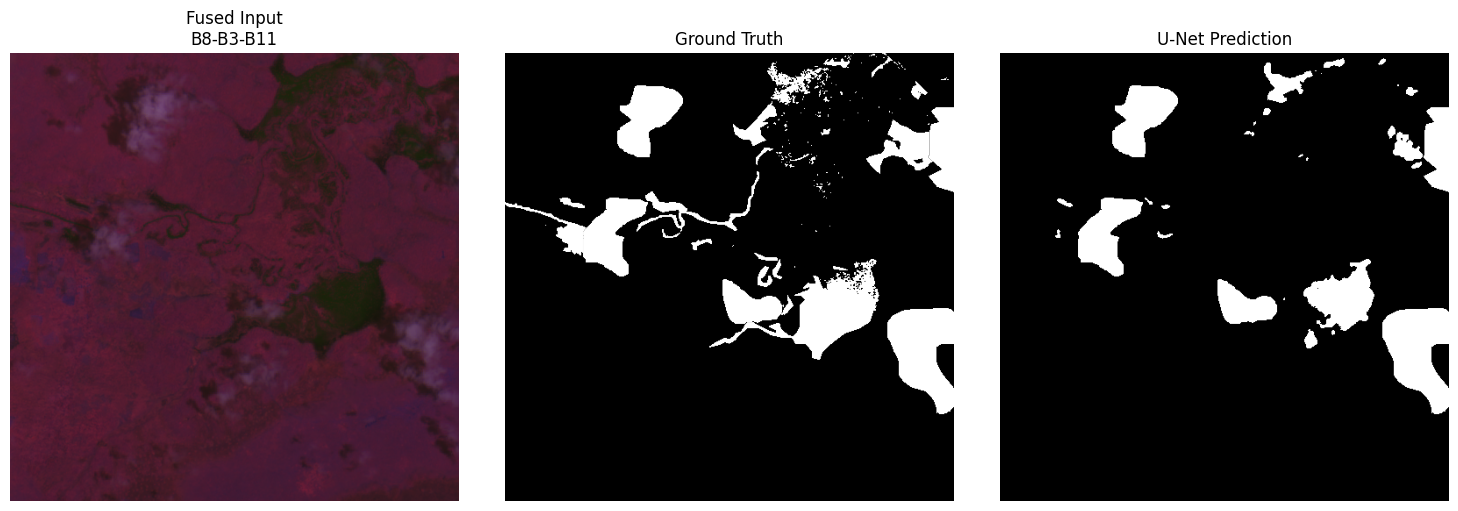

In [31]:
visualize_prediction(
    model,
    fused_test_ds,
    index=0,
    device=device
)

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import torch


def visualize_sar_prediction(model, dataset, index=0, device='cuda'):
    model.eval()
    inputs, labels = dataset[index]
    with torch.no_grad():
        probability = torch.sigmoid(
            model(inputs.unsqueeze(0).to(device))
        )[0, 0].cpu().numpy()

    prediction = probability > 0.5
    label_image = labels[0].numpy()
    valid = label_image >= 0
    truth = label_image.astype(float)
    truth[~valid] = np.nan
    displayed_prediction = prediction.astype(float)
    displayed_prediction[~valid] = np.nan

    figure, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(inputs[0].numpy(), cmap='gray')
    axes[0].set_title('SAR input: VV')
    axes[1].imshow(truth, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Ground truth')
    axes[2].imshow(displayed_prediction, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title('SAR U-Net prediction at 0.5')
    for axis in axes:
        axis.axis('off')
    plt.tight_layout()
    plt.show()

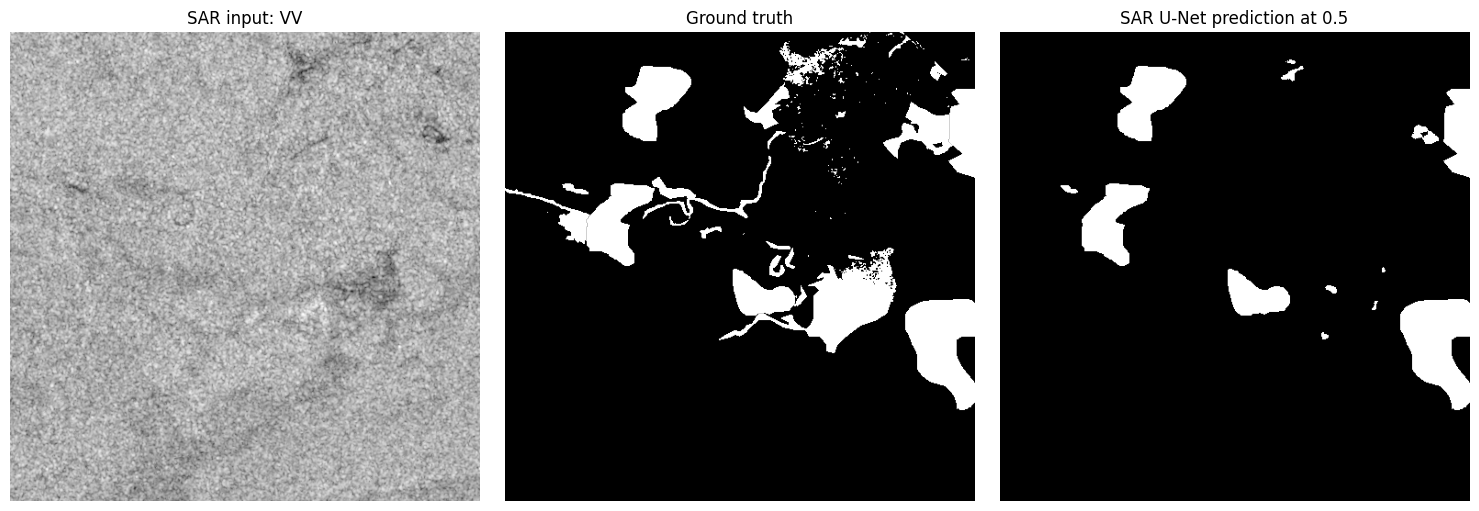

In [33]:
visualize_sar_prediction(
    sar_model,
    sar_test_ds,
    index=0,
    device=device
)

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def compare_sar_fused(
    sar_model,
    fused_model,
    sar_dataset,
    fused_dataset,
    index=0,
    device='cuda'
):
    sar_model.eval()
    fused_model.eval()

    # Same test chip from both datasets
    sar_x, y = sar_dataset[index]
    fused_x, _ = fused_dataset[index]

    with torch.no_grad():
        sar_prob = torch.sigmoid(
            sar_model(sar_x.unsqueeze(0).to(device))
        )[0, 0].cpu().numpy()

        fused_prob = torch.sigmoid(
            fused_model(fused_x.unsqueeze(0).to(device))
        )[0, 0].cpu().numpy()

    sar_pred = sar_prob > 0.5
    fused_pred = fused_prob > 0.5

    y_np = y[0].numpy()
    valid = y_np >= 0

    gt = y_np.astype(float)
    gt[~valid] = np.nan

    sar_pred_display = sar_pred.astype(float)
    sar_pred_display[~valid] = np.nan

    fused_pred_display = fused_pred.astype(float)
    fused_pred_display[~valid] = np.nan

    # Optical false-color visualization from fused input
    rgb = np.stack([
        fused_x[3].numpy(),  # B8
        fused_x[2].numpy(),  # B3
        fused_x[4].numpy()   # B11
    ], axis=-1)

    rgb = np.clip(rgb, 0, 1)

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    axes[0].imshow(rgb)
    axes[0].set_title("Optical Input")
    axes[0].axis("off")

    axes[1].imshow(gt, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(sar_pred_display, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("SAR-only Prediction")
    axes[2].axis("off")

    axes[3].imshow(fused_pred_display, cmap="gray", vmin=0, vmax=1)
    axes[3].set_title("SAR + Optical Prediction")
    axes[3].axis("off")

    # Difference between predictions
    difference = np.zeros((*gt.shape, 3))

    sar_only = sar_pred & valid
    fused_only = fused_pred & valid

    difference[sar_only & ~fused_only] = [1, 0, 0]
    difference[fused_only & ~sar_only] = [0, 1, 0]

    axes[4].imshow(difference)
    axes[4].set_title("Prediction Difference")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()

In [35]:
sar_test_ds = FloodDataset(
    splits['test'],
    mode='sar',
    train=False
)

fused_test_ds = FloodDataset(
    splits['test'],
    mode='fused',
    train=False
)

print("SAR:", len(sar_test_ds))
print("Fused:", len(fused_test_ds))

SAR: 90
Fused: 90


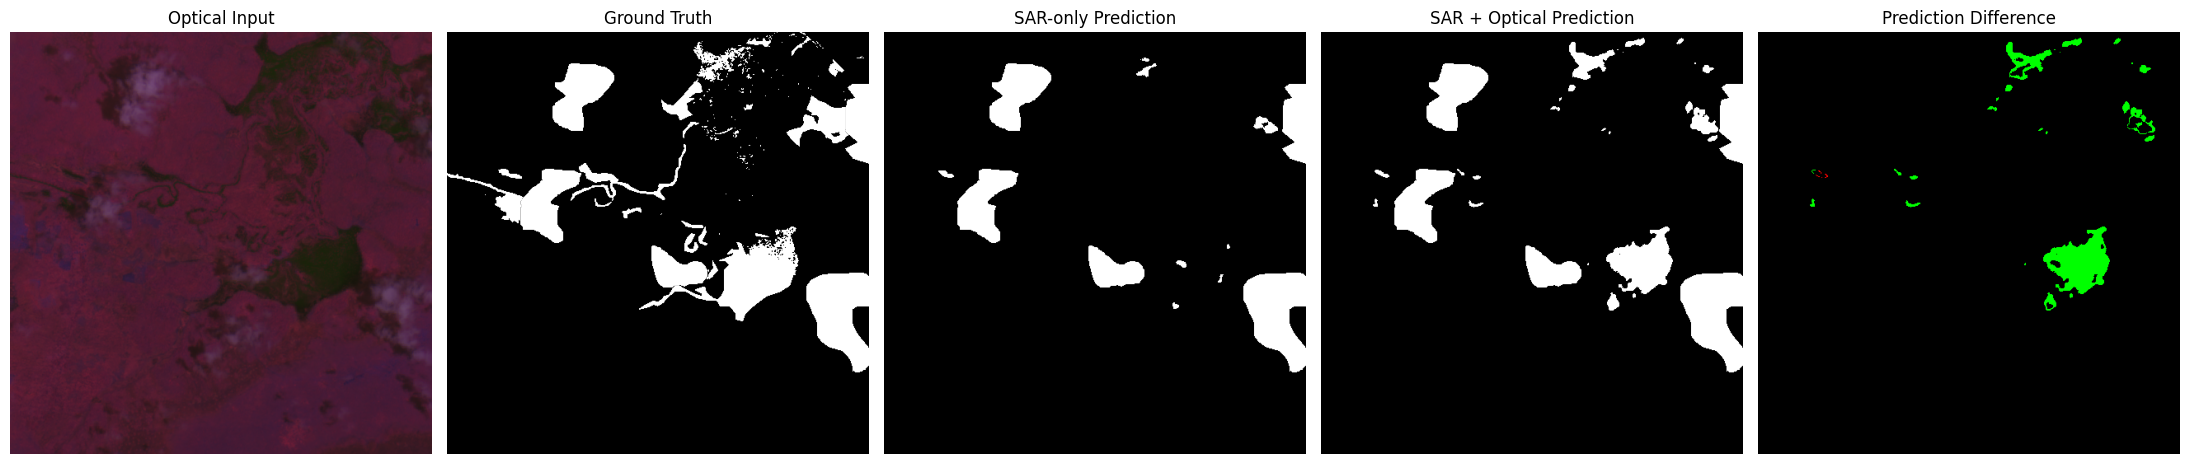

In [36]:
compare_sar_fused(
    sar_model,
    model,
    sar_test_ds,
    fused_test_ds,
    index=0,
    device=device
)

In [37]:
opt_model = smp.Unet(
    'resnet34',
    encoder_weights='imagenet',
    in_channels=4,
    classes=1
).to(device)

print("Optical-only U-Net created.")

Optical-only U-Net created.


In [38]:
opt_train_ds = FloodDataset(
    splits['train'],
    mode='opt',
    train=True,
    crop=256
)

opt_valid_ds = FloodDataset(
    splits['valid'],
    mode='opt',
    train=False
)

print("Training samples:", len(opt_train_ds))
print("Validation samples:", len(opt_valid_ds))

Training samples: 252
Validation samples: 89


In [39]:
opt_train_loader = DataLoader(
    opt_train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

opt_valid_loader = DataLoader(
    opt_valid_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Optical DataLoaders ready.")

Optical DataLoaders ready.


In [40]:
x, y = opt_train_ds[0]

print("Input shape:", x.shape)
print("Label shape:", y.shape)
print("Input min:", x.min().item())
print("Input max:", x.max().item())

Input shape: torch.Size([4, 256, 256])
Label shape: torch.Size([1, 256, 256])
Input min: 0.09189999848604202
Input max: 0.482699990272522


In [41]:
opt_optimizer = torch.optim.AdamW(
    opt_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Optical optimizer ready.")

Optical optimizer ready.


In [42]:
OPT_CHECKPOINT = f'{BASE}/checkpoints/best_opt_unet_seed_{SEEDS[-1]}.pth'
opt_histories = {}

opt seed 7 | epoch 01/30 | loss 1.2376 | val IoU 0.3359
opt seed 7 | epoch 02/30 | loss 1.0352 | val IoU 0.6395
opt seed 7 | epoch 03/30 | loss 0.9306 | val IoU 0.4894
opt seed 7 | epoch 04/30 | loss 0.7797 | val IoU 0.6928
opt seed 7 | epoch 05/30 | loss 0.7660 | val IoU 0.7077
opt seed 7 | epoch 06/30 | loss 0.7420 | val IoU 0.7211
opt seed 7 | epoch 07/30 | loss 0.6400 | val IoU 0.7678
opt seed 7 | epoch 08/30 | loss 0.6550 | val IoU 0.7625
opt seed 7 | epoch 09/30 | loss 0.5950 | val IoU 0.7648
opt seed 7 | epoch 10/30 | loss 0.5703 | val IoU 0.7358
opt seed 7 | epoch 11/30 | loss 0.5448 | val IoU 0.7735
opt seed 7 | epoch 12/30 | loss 0.5717 | val IoU 0.7512
opt seed 7 | epoch 13/30 | loss 0.5382 | val IoU 0.7499
opt seed 7 | epoch 14/30 | loss 0.4840 | val IoU 0.7891
opt seed 7 | epoch 15/30 | loss 0.4918 | val IoU 0.7522
opt seed 7 | epoch 16/30 | loss 0.4580 | val IoU 0.7814
opt seed 7 | epoch 17/30 | loss 0.4622 | val IoU 0.7729
opt seed 7 | epoch 18/30 | loss 0.4479 | val IoU

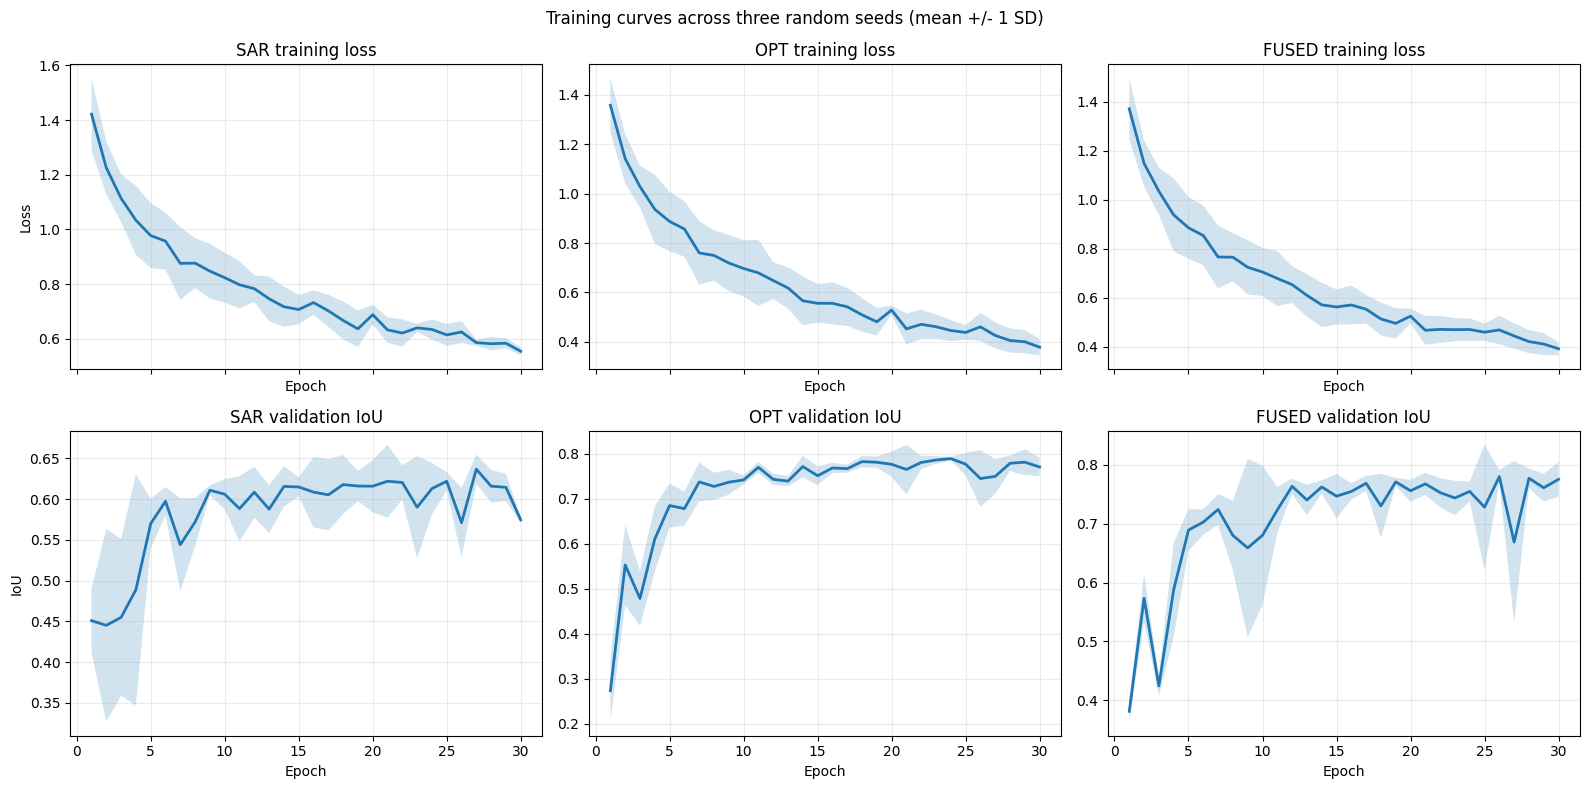

In [43]:
for seed in SEEDS:
    opt_model, opt_histories[seed] = train_one_seed('opt', seed)
histories['opt'] = opt_histories

figure, axes = plt.subplots(2, 3, figsize=(16, 8), sharex='col')
for column, mode in enumerate(('sar', 'opt', 'fused')):
    seed_histories = histories[mode]
    losses = np.asarray([seed_histories[seed]['train_loss'] for seed in SEEDS])
    validation_ious = np.asarray([seed_histories[seed]['val_iou'] for seed in SEEDS])
    epochs = np.arange(1, losses.shape[1] + 1)
    for axis, values, title in (
        (axes[0, column], losses, f'{mode.upper()} training loss'),
        (axes[1, column], validation_ious, f'{mode.upper()} validation IoU'),
    ):
        mean_values = values.mean(axis=0)
        standard_deviation = values.std(axis=0, ddof=1)
        axis.plot(epochs, mean_values, linewidth=2)
        axis.fill_between(
            epochs, mean_values - standard_deviation,
            mean_values + standard_deviation, alpha=0.2
        )
        axis.set_title(title)
        axis.set_xlabel('Epoch')
        axis.grid(alpha=0.25)
axes[0, 0].set_ylabel('Loss')
axes[1, 0].set_ylabel('IoU')
figure.suptitle('Training curves across three random seeds (mean +/- 1 SD)')
figure.tight_layout()
plt.show()

In [44]:
opt_checkpoint = torch.load(OPT_CHECKPOINT, map_location=device)
opt_model.load_state_dict(opt_checkpoint['model_state_dict'])
print('Loaded optical checkpoint for seed:', opt_checkpoint['seed'])
print('Best optical validation metrics:', opt_checkpoint['val_metrics'])

Loaded optical checkpoint for seed: 42
Best optical validation metrics: {'IoU': 0.8008828301889744, 'F1': 0.8894335786464623, 'precision': 0.8652940467913619, 'recall': 0.9149586276398203}


In [45]:
opt_test_ds = FloodDataset(
    splits['test'],
    mode='opt',
    train=False
)

opt_test_loader = DataLoader(
    opt_test_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Optical test samples:", len(opt_test_ds))

Optical test samples: 90


In [46]:
# Create Bolivia dataset and loader for optical-only model

opt_bolivia_ds = FloodDataset(
    splits['bolivia'],
    mode='opt',
    train=False
)

opt_bolivia_loader = DataLoader(
    opt_bolivia_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Optical Bolivia samples:", len(opt_bolivia_ds))

Optical Bolivia samples: 15


In [47]:
# Test datasets for all three models

sar_test_ds = FloodDataset(
    splits['test'],
    mode='sar',
    train=False
)

opt_test_ds = FloodDataset(
    splits['test'],
    mode='opt',
    train=False
)

fused_test_ds = FloodDataset(
    splits['test'],
    mode='fused',
    train=False
)

print("SAR test samples:", len(sar_test_ds))
print("Optical test samples:", len(opt_test_ds))
print("Fused test samples:", len(fused_test_ds))

SAR test samples: 90
Optical test samples: 90
Fused test samples: 90


In [48]:
def collect_model_scores(model, loader, device):
    model.eval()
    probabilities = []
    truth_values = []
    with torch.no_grad():
        for batch_inputs, batch_labels in loader:
            batch_probabilities = torch.sigmoid(
                model(batch_inputs.to(device, non_blocking=True))
            ).squeeze(1).cpu().numpy()
            batch_labels = batch_labels.squeeze(1).cpu().numpy()
            for probability, label_image in zip(batch_probabilities, batch_labels):
                valid = label_image >= 0
                probabilities.append(probability[valid])
                truth_values.append(label_image[valid] == 1)
    return np.concatenate(probabilities), np.concatenate(truth_values)


def collect_ndwi_scores(dataset):
    ndwi_values = []
    truth_values = []
    for sample_index in range(len(dataset)):
        optical_inputs, labels = dataset[sample_index]
        green, nir = optical_inputs[0].numpy(), optical_inputs[1].numpy()
        ndwi = (green - nir) / np.maximum(green + nir, 1e-6)
        label_image = labels[0].numpy()
        valid = label_image >= 0
        ndwi_values.append(ndwi[valid])
        truth_values.append(label_image[valid] == 1)
    return np.concatenate(ndwi_values), np.concatenate(truth_values)


def metrics_at_threshold(scores, truth, threshold):
    prediction = scores >= threshold
    true_positive = np.count_nonzero(prediction & truth)
    false_positive = np.count_nonzero(prediction & ~truth)
    false_negative = np.count_nonzero(~prediction & truth)
    return {
        'IoU': true_positive / max(true_positive + false_positive + false_negative, 1),
        'F1': 2 * true_positive / max(2 * true_positive + false_positive + false_negative, 1),
        'precision': true_positive / max(true_positive + false_positive, 1),
        'recall': true_positive / max(true_positive + false_negative, 1),
    }


def best_validation_threshold(scores, truth, candidates):
    threshold_metrics = [metrics_at_threshold(scores, truth, value) for value in candidates]
    best_index = int(np.argmax([item['IoU'] for item in threshold_metrics]))
    return float(candidates[best_index]), threshold_metrics[best_index]


mode_channels = {'sar': 2, 'opt': 4, 'fused': 6}
validation_scores = {}
results = []
selected_thresholds = {}

for mode, threshold_candidates in [
    ('sar', np.arange(0.20, 0.801, 0.05)),
    ('opt', np.arange(0.20, 0.801, 0.05)),
    ('fused', np.arange(0.20, 0.801, 0.05)),
]:
    validation_loader = DataLoader(
        FloodDataset(splits['valid'], mode=mode, train=False),
        batch_size=8, shuffle=False, num_workers=2, pin_memory=True
    )
    evaluation_loaders = {
        split_name: DataLoader(
            FloodDataset(splits[split_name], mode=mode, train=False),
            batch_size=8, shuffle=False, num_workers=2, pin_memory=True
        )
        for split_name in ('test', 'bolivia')
    }

    for seed in SEEDS:
        model = smp.Unet(
            'resnet34', encoder_weights=None,
            in_channels=mode_channels[mode], classes=1
        ).to(device)
        checkpoint_path = f'{BASE}/checkpoints/best_{mode}_unet_seed_{seed}.pth'
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])

        validation_scores[(mode, seed)] = collect_model_scores(
            model, validation_loader, device
        )
        validation_probability, validation_truth = validation_scores[(mode, seed)]
        threshold, validation_metrics = best_validation_threshold(
            validation_probability, validation_truth, threshold_candidates
        )
        selected_thresholds[(mode, seed)] = threshold
        print(
            f'{mode} seed {seed}: validation-selected threshold={threshold:.2f}, '
            f'validation IoU={validation_metrics["IoU"]:.3f}'
        )

        for split_name, evaluation_loader in evaluation_loaders.items():
            scores, truth = collect_model_scores(model, evaluation_loader, device)
            results.append({
                'model': mode.upper(), 'seed': seed, 'split': split_name.title(),
                **metrics_at_threshold(scores, truth, threshold),
            })
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

ndwi_validation = FloodDataset(splits['valid'], mode='opt', train=False)
ndwi_threshold, ndwi_validation_metrics = best_validation_threshold(
    *collect_ndwi_scores(ndwi_validation),
    np.arange(-0.20, 0.601, 0.025)
)
for split_name in ('test', 'bolivia'):
    ndwi_dataset = FloodDataset(splits[split_name], mode='opt', train=False)
    ndwi_scores, ndwi_truth = collect_ndwi_scores(ndwi_dataset)
    results.append({
        'model': f'NDWI (threshold {ndwi_threshold:.3f})',
        'seed': 'fixed', 'split': split_name.title(),
        **metrics_at_threshold(ndwi_scores, ndwi_truth, ndwi_threshold),
    })

metrics_frame = pd.DataFrame(results)
summary_rows = []
for (model_name, split_name), group in metrics_frame.groupby(['model', 'split'], sort=False):
    row = {'Model': model_name, 'Evaluation': split_name, 'n': len(group)}
    for metric_name in ('IoU', 'F1', 'precision', 'recall'):
        mean_value = group[metric_name].mean()
        standard_deviation = group[metric_name].std(ddof=1)
        row[metric_name] = (
            f'{mean_value:.3f} +/- {standard_deviation:.3f}'
            if len(group) > 1 else f'{mean_value:.3f} (single deterministic baseline)'
        )
    summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows)
print(f'NDWI threshold selected on validation only: {ndwi_threshold:.3f}')
print(
    f'Bolivia geographic evaluation: {len(splits["bolivia"])} chips, '
    f'{len(region_sets["bolivia"])} geographic region(s); interpret cautiously.'
)
display(summary_table)

sar seed 7: validation-selected threshold=0.55, validation IoU=0.657
sar seed 21: validation-selected threshold=0.60, validation IoU=0.657
sar seed 42: validation-selected threshold=0.50, validation IoU=0.638
opt seed 7: validation-selected threshold=0.45, validation IoU=0.799
opt seed 21: validation-selected threshold=0.50, validation IoU=0.804
opt seed 42: validation-selected threshold=0.60, validation IoU=0.803
fused seed 7: validation-selected threshold=0.45, validation IoU=0.792
fused seed 21: validation-selected threshold=0.60, validation IoU=0.804
fused seed 42: validation-selected threshold=0.35, validation IoU=0.782
NDWI threshold selected on validation only: -0.075
Bolivia geographic evaluation: 15 chips, 1 geographic region(s); interpret cautiously.


,Model,Evaluation,n,IoU,F1,precision,recall
0,SAR,Test,3,0.662 +/- 0.013,0.796 +/- 0.010,0.819 +/- 0.031,0.776 +/- 0.028
1,SAR,Bolivia,3,0.609 +/- 0.053,0.756 +/- 0.042,0.785 +/- 0.006,0.731 +/- 0.071
2,OPT,Test,3,0.836 +/- 0.006,0.911 +/- 0.004,0.911 +/- 0.004,0.910 +/- 0.006
3,OPT,Bolivia,3,0.797 +/- 0.010,0.887 +/- 0.006,0.913 +/- 0.015,0.863 +/- 0.024
4,FUSED,Test,3,0.811 +/- 0.012,0.896 +/- 0.007,0.897 +/- 0.010,0.894 +/- 0.005
5,FUSED,Bolivia,3,0.743 +/- 0.008,0.852 +/- 0.005,0.829 +/- 0.032,0.878 +/- 0.028
6,NDWI (threshold -0.075),Test,1,0.742 (single deterministic baseline),0.852 (single deterministic baseline),0.801 (single deterministic baseline),0.910 (single deterministic baseline)
7,NDWI (threshold -0.075),Bolivia,1,0.796 (single deterministic baseline),0.886 (single deterministic baseline),0.845 (single deterministic baseline),0.932 (single deterministic baseline)


In [49]:
# Check actual U-Net prediction for one test image

idx = 0

x, y = opt_test_ds[idx]

opt_model.eval()

with torch.no_grad():
    prob = torch.sigmoid(
        opt_model(x.unsqueeze(0).to(device))
    )[0, 0].cpu().numpy()

print("Input shape:", x.shape)
print("Prediction shape:", prob.shape)

print("Prediction minimum:", prob.min())
print("Prediction maximum:", prob.max())
print("Prediction mean:", prob.mean())

print("Pixels > 0.5:", (prob > 0.5).sum())
print("Total pixels:", prob.size)
print("Predicted water percentage:",
      100 * (prob > 0.5).mean())

print("Ground-truth water percentage:",
      100 * ((y[0].numpy() == 1).sum() / (y[0].numpy() >= 0).sum()))

Input shape: torch.Size([4, 512, 512])
Prediction shape: (512, 512)
Prediction minimum: 0.0022375197
Prediction maximum: 0.9992778
Prediction mean: 0.049282067
Pixels > 0.5: 9149
Total pixels: 262144
Predicted water percentage: 3.4900665283203125
Ground-truth water percentage: 6.108465868185091


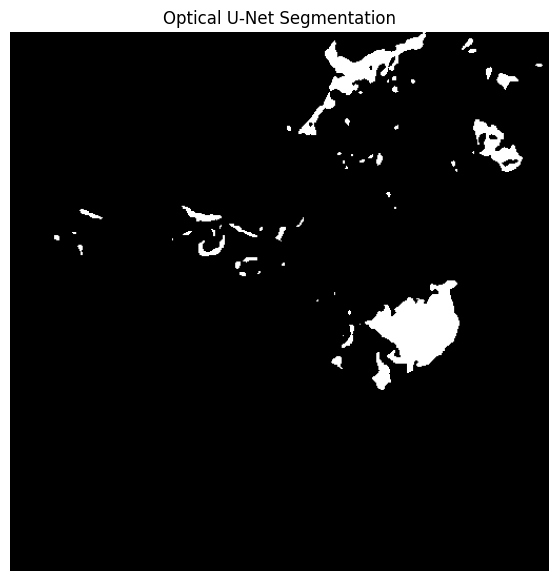

In [50]:
prediction = prob > 0.5

plt.figure(figsize=(7, 7))

plt.imshow(prediction, cmap="gray", vmin=0, vmax=1)

plt.title("Optical U-Net Segmentation")

plt.axis("off")

plt.show()

In [51]:
import segmentation_models_pytorch as smp

fused_model = smp.Unet(
    'resnet34', encoder_weights=None, in_channels=6, classes=1
).to(device)
fused_checkpoint_path = f'{BASE}/checkpoints/best_fused_unet_seed_{SEEDS[-1]}.pth'
fused_checkpoint = torch.load(fused_checkpoint_path, map_location=device)
fused_model.load_state_dict(fused_checkpoint['model_state_dict'])
fused_model.eval()
print('Loaded fused checkpoint for seed:', fused_checkpoint['seed'])
print('Best validation metrics:', fused_checkpoint['val_metrics'])

Loaded fused checkpoint for seed: 42
Best validation metrics: {'IoU': 0.7772823406602551, 'F1': 0.8746863938022329, 'precision': 0.9085670067698003, 'recall': 0.8432417696599712}


In [52]:
sar_test_ds = FloodDataset(
    splits['test'],
    mode='sar',
    train=False
)

opt_test_ds = FloodDataset(
    splits['test'],
    mode='opt',
    train=False
)

fused_test_ds = FloodDataset(
    splits['test'],
    mode='fused',
    train=False
)

print("SAR:", len(sar_test_ds))
print("Optical:", len(opt_test_ds))
print("Fused:", len(fused_test_ds))

SAR: 90
Optical: 90
Fused: 90


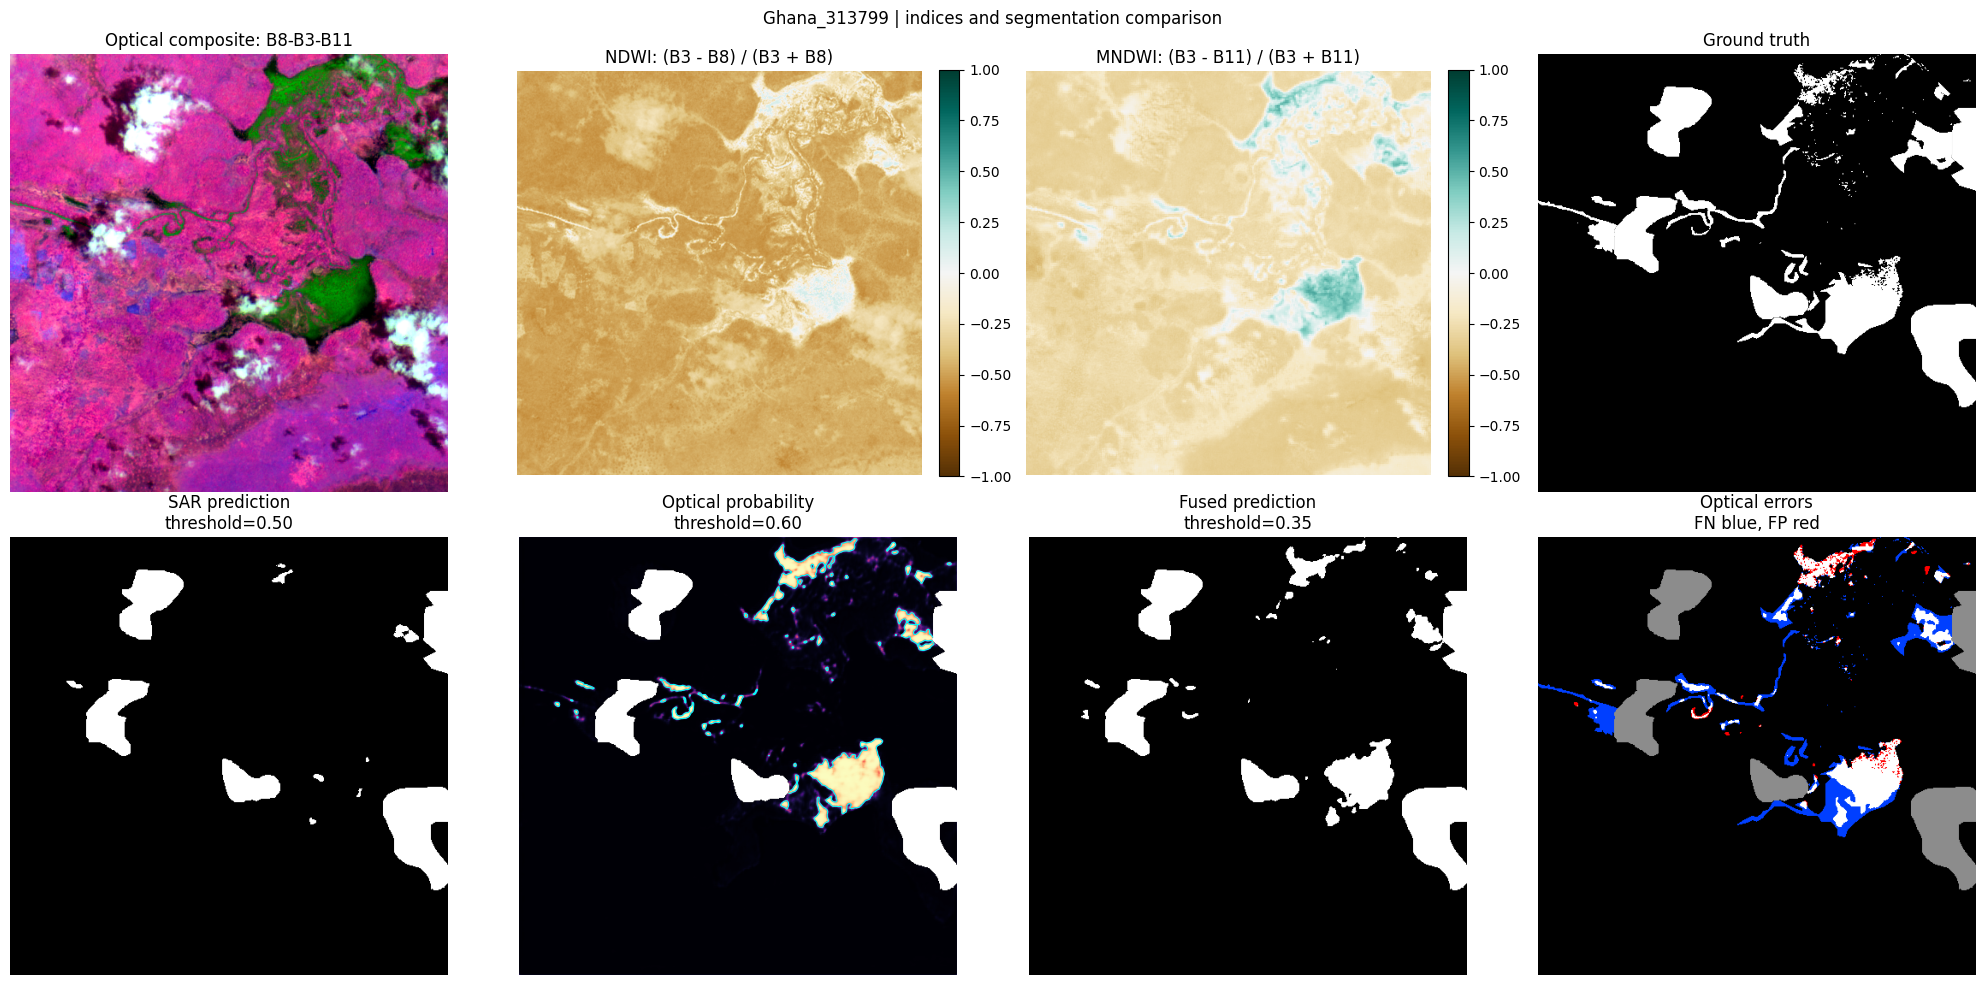

Optical seed 42: threshold=0.60, predicted water=3.5%, ground truth=6.1%, false-negative share of water=50.7%


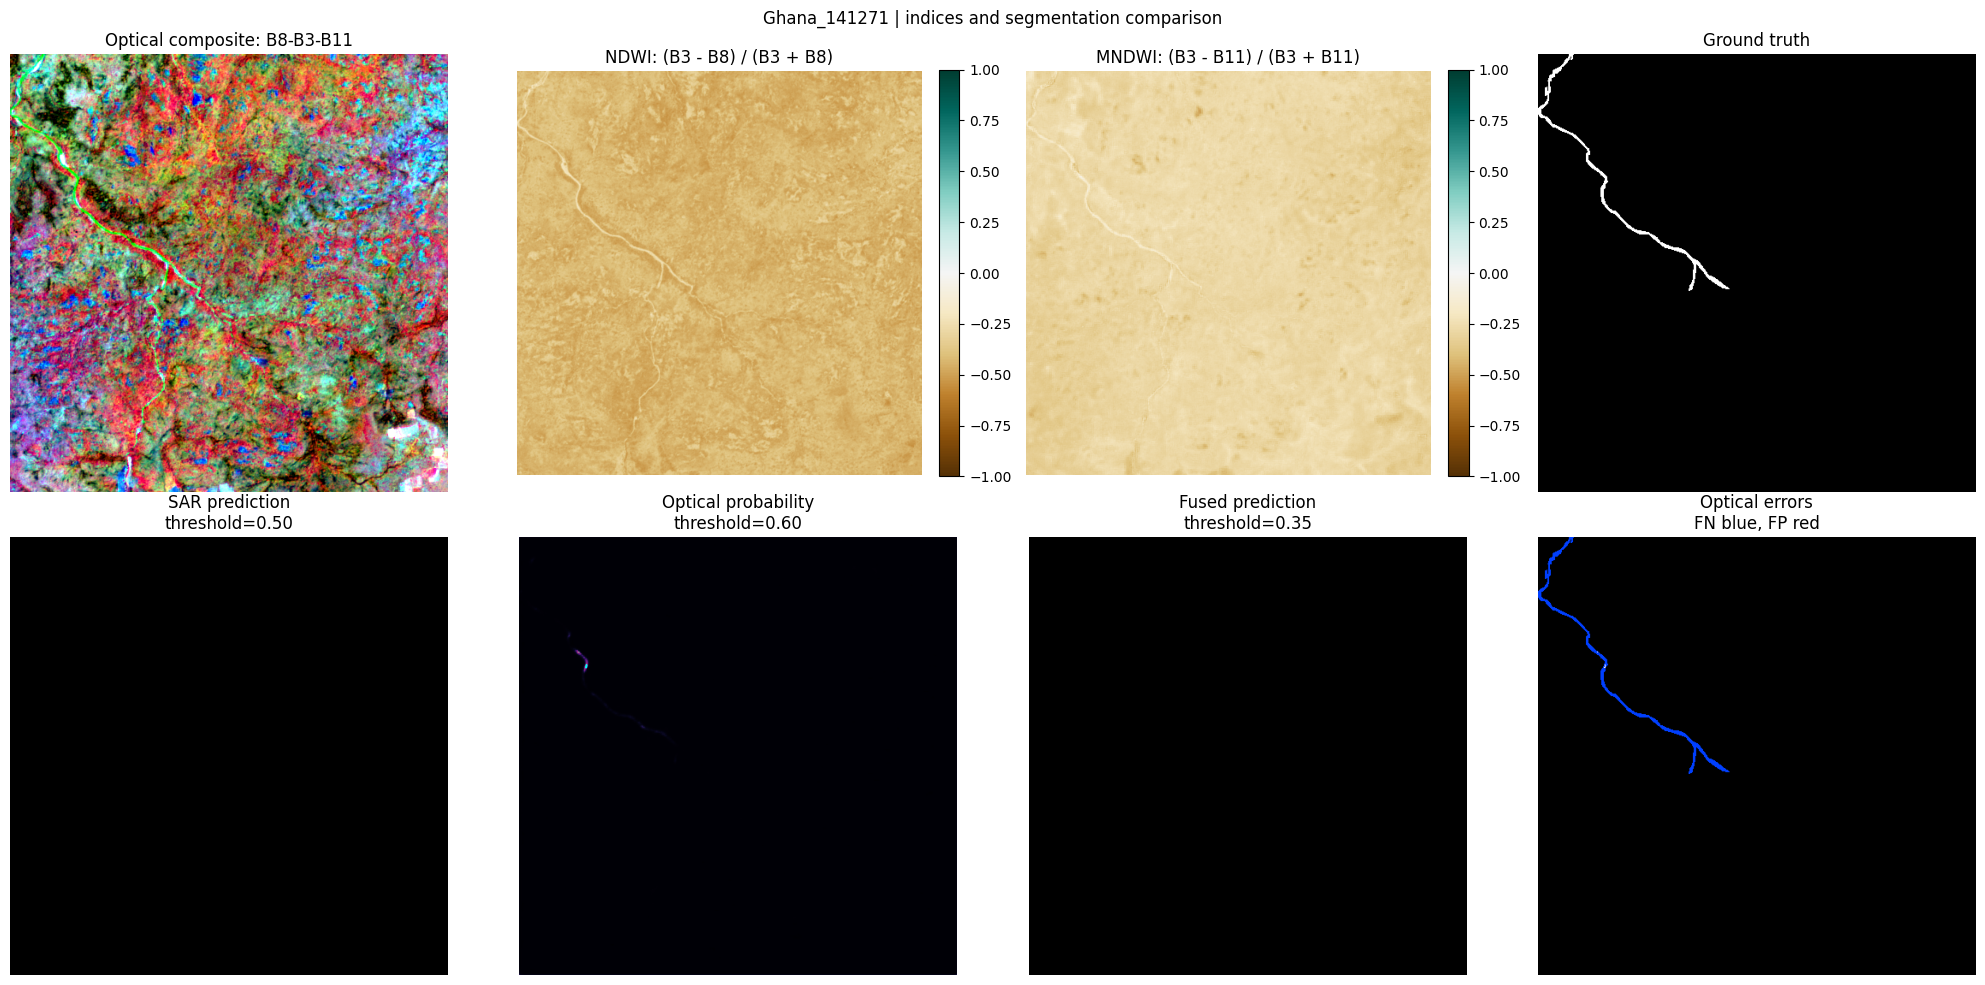

Optical seed 42: threshold=0.60, predicted water=0.0%, ground truth=0.6%, false-negative share of water=99.6%


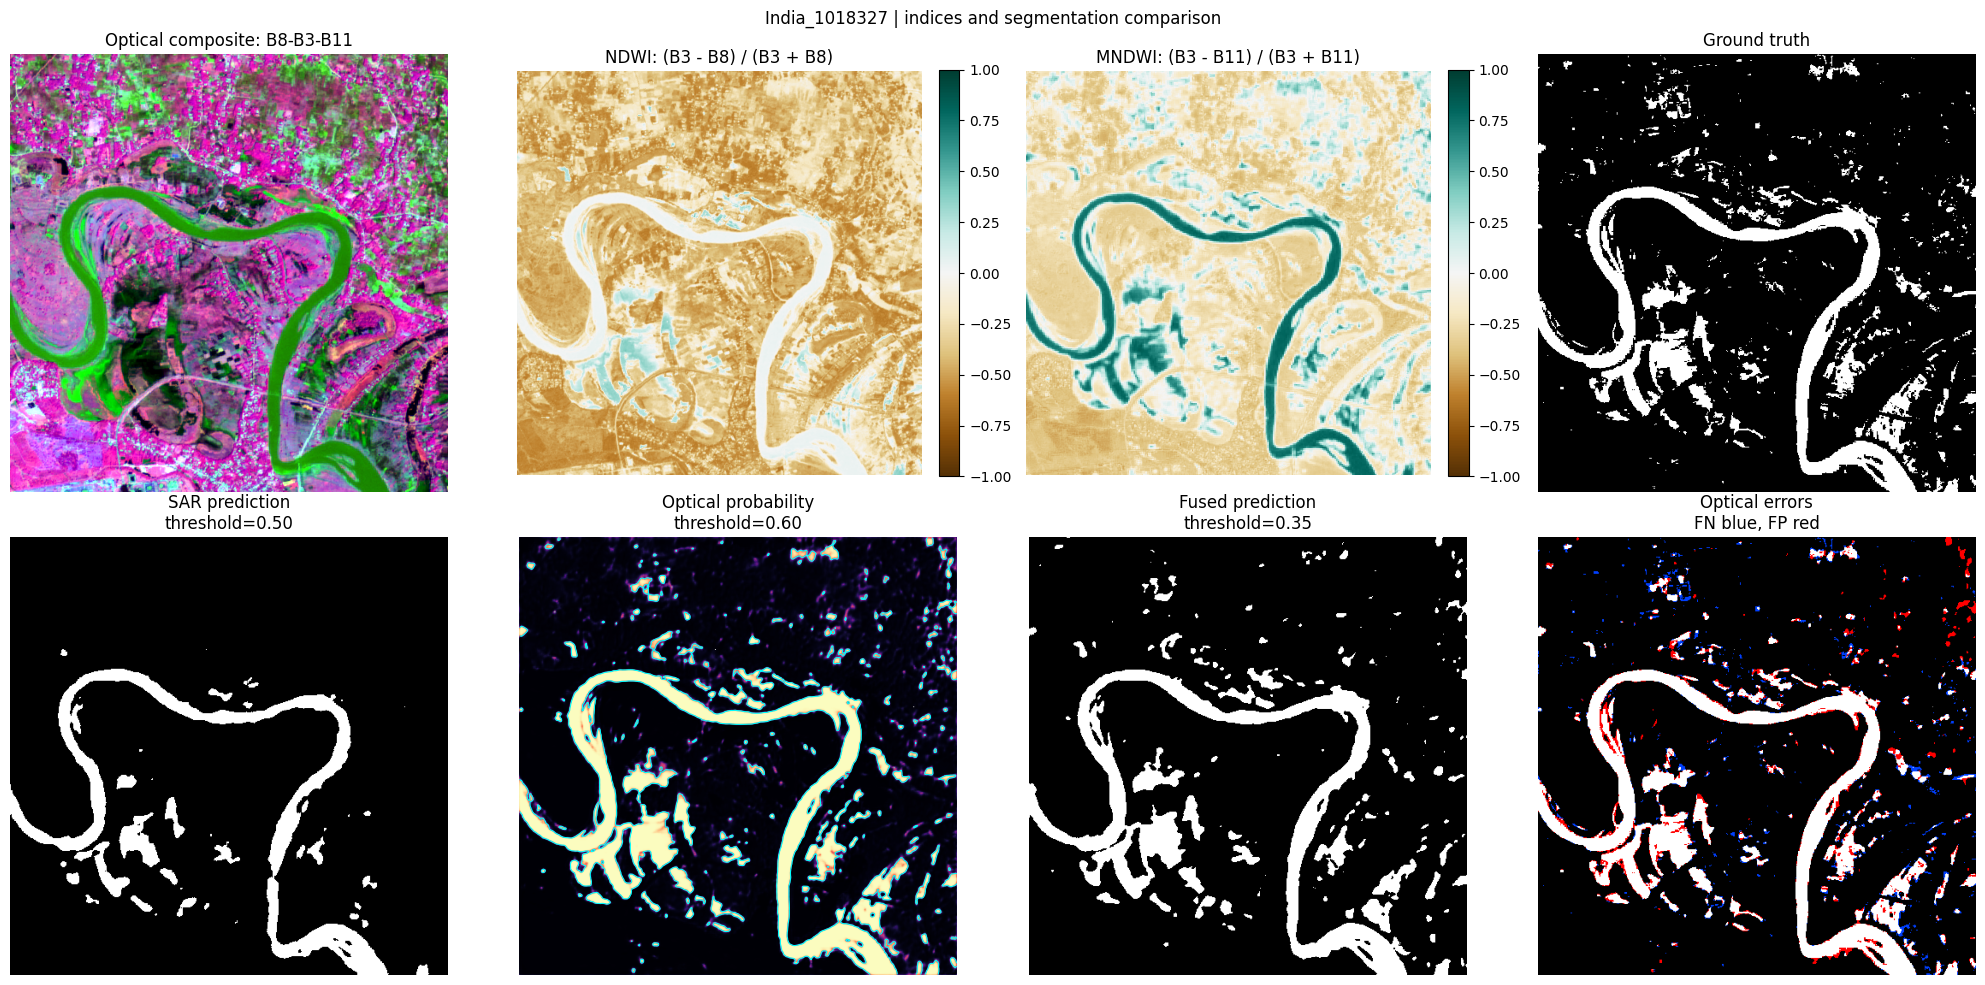

Optical seed 42: threshold=0.60, predicted water=14.7%, ground truth=14.0%, false-negative share of water=10.8%


In [53]:
def show_segmentation_comparison(index=0, threshold=None):
    sar_inputs, _ = sar_test_ds[index]
    optical_inputs, optical_labels = opt_test_ds[index]
    fused_inputs, _ = fused_test_ds[index]
    label_image = optical_labels[0].numpy()
    valid = label_image >= 0
    truth = label_image == 1
    thresholds = {
        'SAR': selected_thresholds[('sar', SEEDS[-1])],
        'Optical': selected_thresholds[('opt', SEEDS[-1])],
        'Fused': selected_thresholds[('fused', SEEDS[-1])],
    }
    if threshold is not None:
        thresholds['Optical'] = threshold

    model_inputs = {
        'SAR': (sar_model, sar_inputs),
        'Optical': (opt_model, optical_inputs),
        'Fused': (fused_model, fused_inputs),
    }
    probabilities = {}
    predictions = {}
    for model_name, (model, inputs) in model_inputs.items():
        model.eval()
        with torch.no_grad():
            probability = torch.sigmoid(
                model(inputs.unsqueeze(0).to(device))
            )[0, 0].cpu().numpy()
        probabilities[model_name] = probability
        predictions[model_name] = probability >= thresholds[model_name]

    green = optical_inputs[0].numpy()
    nir = optical_inputs[1].numpy()
    swir1 = optical_inputs[2].numpy()
    ndwi = (green - nir) / np.maximum(green + nir, 1e-6)
    mndwi = (green - swir1) / np.maximum(green + swir1, 1e-6)

    rgb = np.stack([nir, green, swir1], axis=-1)
    lower = np.percentile(rgb, 2, axis=(0, 1))
    upper = np.percentile(rgb, 98, axis=(0, 1))
    rgb = np.clip((rgb - lower) / np.maximum(upper - lower, 1e-6), 0, 1)
    truth_display = truth.astype(float)
    truth_display[~valid] = np.nan
    optical_probability = probabilities['Optical'].copy()
    optical_probability[~valid] = np.nan

    optical_prediction = predictions['Optical']
    error_colors = np.zeros((*truth.shape, 3), dtype=float)
    error_colors[optical_prediction & truth & valid] = [1, 1, 1]
    error_colors[optical_prediction & ~truth & valid] = [1, 0, 0]
    error_colors[~optical_prediction & truth & valid] = [0, 0.25, 1]
    error_colors[~valid] = [0.55, 0.55, 0.55]

    figure, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.ravel()
    axes[0].imshow(rgb)
    axes[0].set_title('Optical composite: B8-B3-B11')
    ndwi_image = axes[1].imshow(ndwi, cmap='BrBG', vmin=-1, vmax=1)
    axes[1].set_title('NDWI: (B3 - B8) / (B3 + B8)')
    figure.colorbar(ndwi_image, ax=axes[1], fraction=0.046, pad=0.04)
    mndwi_image = axes[2].imshow(mndwi, cmap='BrBG', vmin=-1, vmax=1)
    axes[2].set_title('MNDWI: (B3 - B11) / (B3 + B11)')
    figure.colorbar(mndwi_image, ax=axes[2], fraction=0.046, pad=0.04)
    axes[3].imshow(truth_display, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title('Ground truth')

    for axis, model_name in ((axes[4], 'SAR'), (axes[6], 'Fused')):
        display_prediction = predictions[model_name].astype(float)
        display_prediction[~valid] = np.nan
        axis.imshow(display_prediction, cmap='gray', vmin=0, vmax=1)
        axis.set_title(f'{model_name} prediction\nthreshold={thresholds[model_name]:.2f}')
    axes[5].imshow(optical_probability, cmap='magma', vmin=0, vmax=1)
    axes[5].contour(
        optical_probability, levels=[thresholds['Optical']], colors='cyan', linewidths=0.8
    )
    axes[5].set_title(f'Optical probability\nthreshold={thresholds["Optical"]:.2f}')
    axes[7].imshow(error_colors)
    axes[7].set_title('Optical errors\nFN blue, FP red')
    for axis in axes:
        axis.axis('off')
    figure.suptitle(f'{opt_test_ds.ids[index]} | indices and segmentation comparison')
    figure.tight_layout()
    plt.show()

    valid_water = truth & valid
    false_negative_fraction = (
        np.count_nonzero(~optical_prediction & valid_water) / max(np.count_nonzero(valid_water), 1)
    )
    predicted_fraction = np.count_nonzero(optical_prediction & valid) / max(np.count_nonzero(valid), 1)
    truth_fraction = np.count_nonzero(valid_water) / max(np.count_nonzero(valid), 1)
    print(
        f'Optical seed {SEEDS[-1]}: threshold={thresholds["Optical"]:.2f}, '
        f'predicted water={predicted_fraction:.1%}, ground truth={truth_fraction:.1%}, '
        f'false-negative share of water={false_negative_fraction:.1%}'
    )


for scene_index in [0, 10, 20]:
    show_segmentation_comparison(index=scene_index)

In [54]:
def create_error_map(model, x, y, device='cuda', threshold=0.5):
    model.eval()

    with torch.no_grad():
        prob = torch.sigmoid(
            model(x.unsqueeze(0).to(device))
        )[0, 0].cpu().numpy()

    pred = prob >= threshold

    gt = y[0].numpy()
    valid = gt >= 0
    gt_binary = gt == 1

    error_map = np.zeros((*gt.shape, 3))

    # True Negative = black
    tn = (~pred) & (~gt_binary) & valid
    error_map[tn] = [0, 0, 0]

    # True Positive = white
    tp = pred & gt_binary & valid
    error_map[tp] = [1, 1, 1]

    # False Positive = red
    fp = pred & (~gt_binary) & valid
    error_map[fp] = [1, 0, 0]

    # False Negative = blue
    fn = (~pred) & gt_binary & valid
    error_map[fn] = [0, 0, 1]

    # Invalid pixels
    error_map[~valid] = [1, 1, 1]

    return error_map, prob

In [55]:
def show_error_comparison(index=0, threshold=0.5):

    sar_x, sar_y = sar_test_ds[index]
    opt_x, opt_y = opt_test_ds[index]
    fused_x, fused_y = fused_test_ds[index]

    sar_error, sar_prob = create_error_map(
        sar_model, sar_x, sar_y, device, threshold
    )

    opt_error, opt_prob = create_error_map(
        opt_model, opt_x, opt_y, device, threshold
    )

    fused_error, fused_prob = create_error_map(
        fused_model, fused_x, fused_y, device, threshold
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(sar_error)
    axes[0].set_title("SAR-only Error Map")
    axes[0].axis("off")

    axes[1].imshow(opt_error)
    axes[1].set_title("Optical-only Error Map")
    axes[1].axis("off")

    axes[2].imshow(fused_error)
    axes[2].set_title("SAR + Optical Error Map")
    axes[2].axis("off")

    plt.suptitle(
        f"Segmentation Error Comparison — Test Scene {index}",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()

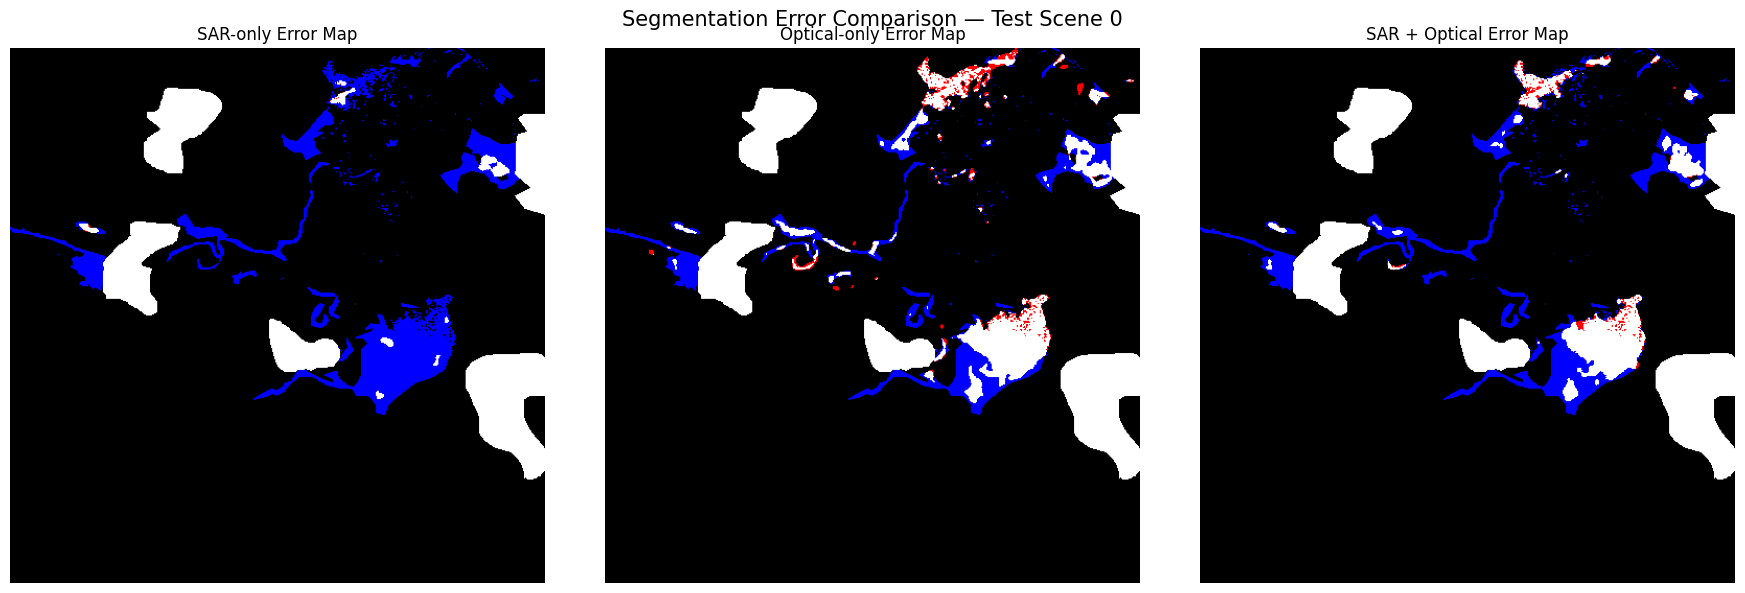

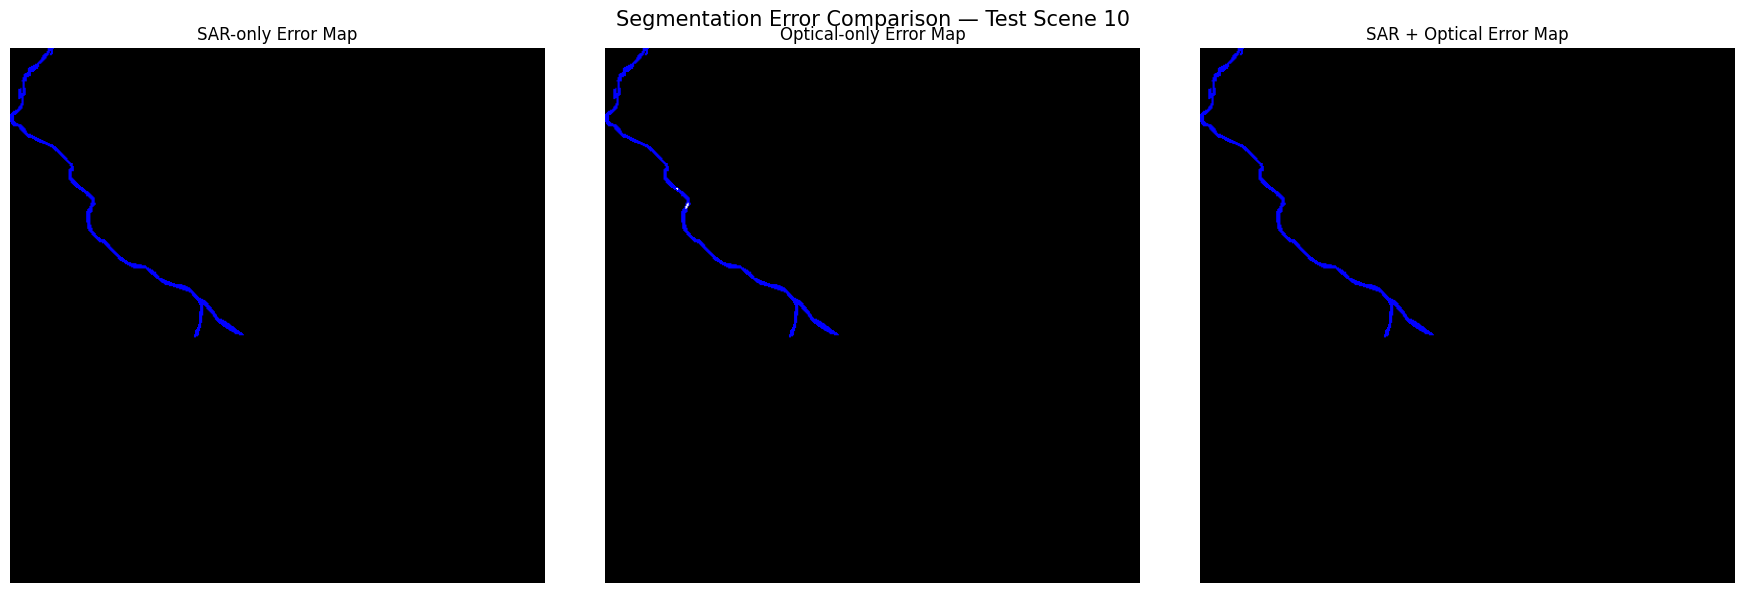

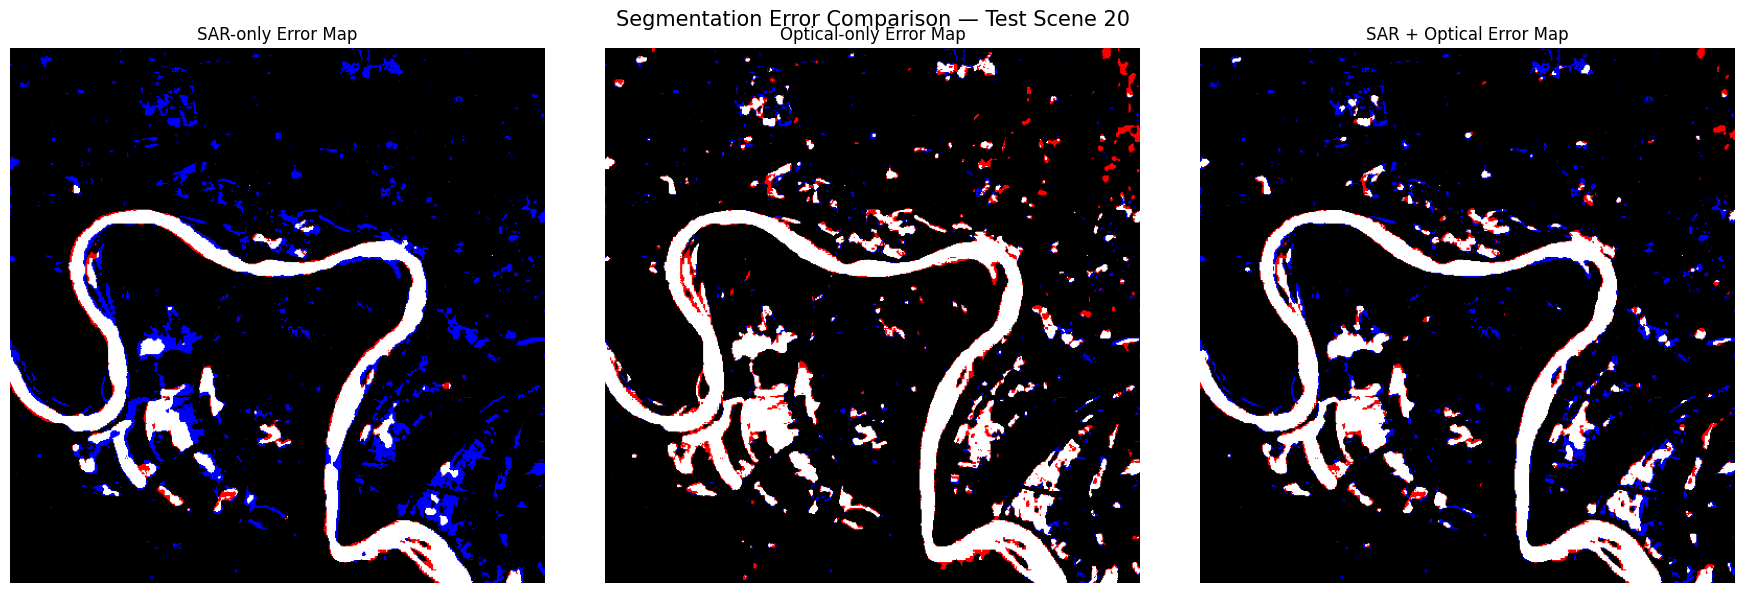

In [56]:
for idx in [0, 10, 20]:
    show_error_comparison(index=idx)

,Split,Metric,NDWI baseline,Optical U-Net mean,Optical U-Net SD across seeds,U-Net gain (percentage points)
0,Test,IoU,0.742,0.836,0.006,9.347
1,Test,F1,0.852,0.911,0.004,5.844
2,Bolivia,IoU,0.796,0.797,0.010,0.076
3,Bolivia,F1,0.886,0.887,0.006,0.045


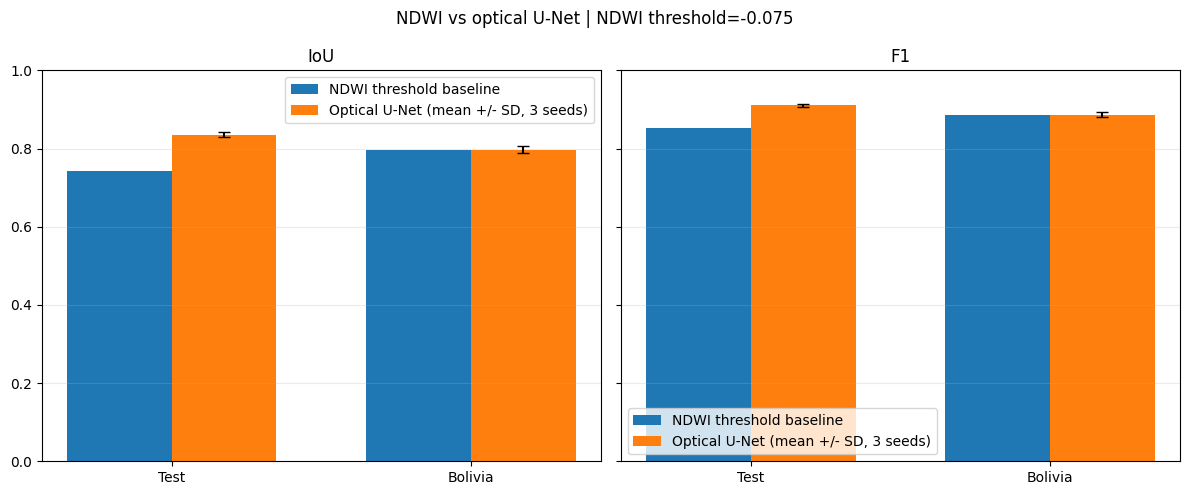

In [57]:
# Compare the validation-tuned NDWI baseline with the optical-only U-Net.
ndwi_model_name = next(
    name for name in metrics_frame['model'].unique()
    if str(name).startswith('NDWI')
)
evaluation_splits = ['Test', 'Bolivia']
comparison_rows = []

for split_name in evaluation_splits:
    ndwi_result = metrics_frame[
        (metrics_frame['model'] == ndwi_model_name) &
        (metrics_frame['split'] == split_name)
    ].iloc[0]
    optical_results = metrics_frame[
        (metrics_frame['model'] == 'OPT') &
        (metrics_frame['split'] == split_name)
    ]

    for metric_name in ['IoU', 'F1']:
        optical_mean = optical_results[metric_name].mean()
        optical_sd = optical_results[metric_name].std(ddof=1)
        comparison_rows.append({
            'Split': split_name,
            'Metric': metric_name,
            'NDWI baseline': ndwi_result[metric_name],
            'Optical U-Net mean': optical_mean,
            'Optical U-Net SD across seeds': optical_sd,
            'U-Net gain (percentage points)': 100 * (optical_mean - ndwi_result[metric_name]),
        })

comparison_table = pd.DataFrame(comparison_rows)
display(comparison_table.round(3))

figure, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
positions = np.arange(len(evaluation_splits))
bar_width = 0.35

for axis, metric_name in zip(axes, ['IoU', 'F1']):
    metric_rows = comparison_table[comparison_table['Metric'] == metric_name]
    ndwi_values = metric_rows['NDWI baseline'].to_numpy()
    optical_values = metric_rows['Optical U-Net mean'].to_numpy()
    optical_errors = metric_rows['Optical U-Net SD across seeds'].fillna(0).to_numpy()

    axis.bar(
        positions - bar_width / 2, ndwi_values, bar_width,
        label='NDWI threshold baseline'
    )
    axis.bar(
        positions + bar_width / 2, optical_values, bar_width,
        yerr=optical_errors, capsize=4,
        label='Optical U-Net (mean +/- SD, 3 seeds)'
    )
    axis.set_title(metric_name)
    axis.set_xticks(positions)
    axis.set_xticklabels(evaluation_splits)
    axis.set_ylim(0, 1)
    axis.grid(axis='y', alpha=0.25)
    axis.legend()

figure.suptitle(f'NDWI vs optical U-Net | NDWI threshold={ndwi_threshold:.3f}')
figure.tight_layout()
plt.show()